# 11. Convolutional Neural Networks (CNNs)
---

MLPs treat every pixel independently and have no sense of spatial structure. **CNNs** exploit the fact that nearby pixels are related — making them dramatically more effective for images.


## 11.1 The Problem with MLPs on Images

A 28×28 grayscale image has **784** pixels. An MLP connects every input to every hidden neuron:
- 784 inputs × 256 hidden = **200,704 parameters** in just the first layer
- For a 224×224 RGB image: 3 × 224 × 224 × 256 = **38 million parameters**

This is:
- 💸 Computationally expensive
- 🎲 Prone to overfitting
- 🙈 Ignores spatial structure (a cat eye looks the same whether it's in the top-left or bottom-right)

**CNNs solve this with two ideas:** local connectivity and weight sharing.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
print("Libraries loaded ✓")


Libraries loaded ✓


## 11.2 The Convolution Operation

A **filter** (kernel) is a small matrix (e.g. 3×3) that slides over the image.
At each position it computes a **dot product** with the patch of pixels underneath.

This produces a **feature map** — highlighting where a pattern (edge, curve, texture) appears.

```
Image patch:        Filter (edge detector):    Output:
1 1 1 0 0          1  0 -1                     strong
1 1 0 0 0    ×     1  0 -1          →          response
1 0 0 0 0          1  0 -1                     (vertical edge found)
```

Key properties:
- **Same filter**, different positions → **weight sharing** (huge parameter reduction)
- **Local connectivity** → each output neuron only sees a small region (**receptive field**)


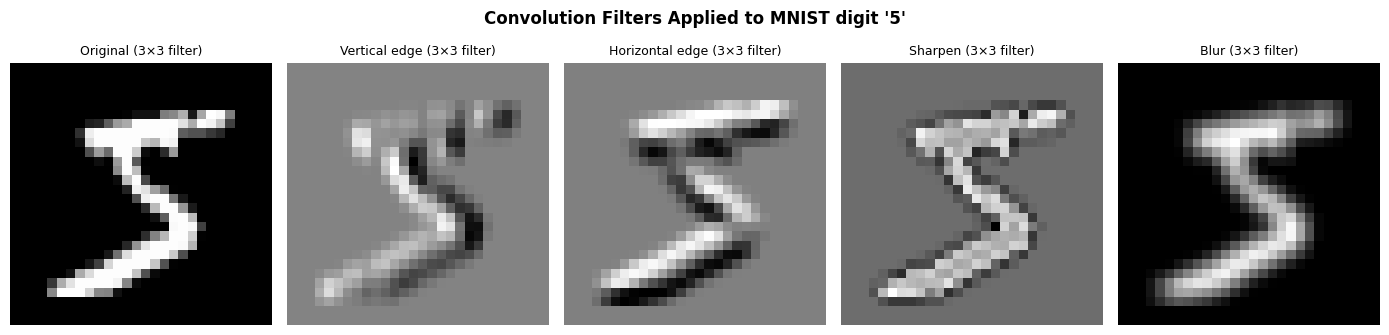

In [6]:
# Visualize convolution with hand-crafted filters
def apply_filter(image_np, kernel):
    # Apply a 2D convolution filter using PyTorch.
    img_t   = torch.from_numpy(image_np).float().unsqueeze(0).unsqueeze(0)
    k_t     = torch.from_numpy(kernel).float().unsqueeze(0).unsqueeze(0)
    out     = F.conv2d(img_t, k_t, padding=1)
    return out.squeeze().numpy()

# Load one MNIST sample
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
img, label = mnist[0]
img_np = img.squeeze().numpy()

# Hand-crafted filters
filters = {
    "Original":        np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
    "Vertical edge":   np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "Horizontal edge": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    "Sharpen":         np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
    "Blur":            np.ones((3,3), dtype=np.float32) / 9,
}

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
for ax, (name, kernel) in zip(axes, filters.items()):
    result = apply_filter(img_np, kernel)
    ax.imshow(result, cmap='gray')
    ax.set_title(f"{name} (3×3 filter)", fontsize=9)
    ax.axis('off')

plt.suptitle(f"Convolution Filters Applied to MNIST digit '{label}'", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 11.3 Key CNN Concepts

### Padding
Add zeros around the border so the output has the **same spatial size** as the input.
- `padding=0` → output shrinks
- `padding=1` (for 3×3 kernel) → output same size as input ("same" padding)

### Stride
How many pixels the filter **steps** each time.
- `stride=1` → output nearly same size as input
- `stride=2` → output half the size (common for downsampling)

### Multiple Filters → Multiple Feature Maps
A conv layer has $N$ filters → produces $N$ feature maps (channels).
Each filter learns to detect a different pattern.

### Pooling
After convolution, **pooling** reduces spatial size by taking the max or average over a small region.
- `MaxPool2d(2,2)` → halves both height and width, keeps the strongest activation


In [7]:
# Demonstrate padding and stride effects
conv_same  = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=1)
conv_shrink = nn.Conv2d(1, 1, kernel_size=3, padding=0, stride=1)
conv_stride = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
pool        = nn.MaxPool2d(kernel_size=2, stride=2)

x = torch.randn(1, 1, 28, 28)   # (batch, channels, H, W)

print("Input:            ", x.shape)
print("Conv(pad=1,s=1):  ", conv_same(x).shape,   "← same spatial size")
print("Conv(pad=0,s=1):  ", conv_shrink(x).shape,  "← shrinks by 2 each side")
print("Conv(pad=1,s=2):  ", conv_stride(x).shape,  "← halved by stride")
print("MaxPool(2,2):     ", pool(x).shape,          "← halved by pooling")


Input:             torch.Size([1, 1, 28, 28])
Conv(pad=1,s=1):   torch.Size([1, 1, 28, 28]) ← same spatial size
Conv(pad=0,s=1):   torch.Size([1, 1, 26, 26]) ← shrinks by 2 each side
Conv(pad=1,s=2):   torch.Size([1, 1, 14, 14]) ← halved by stride
MaxPool(2,2):      torch.Size([1, 1, 14, 14]) ← halved by pooling


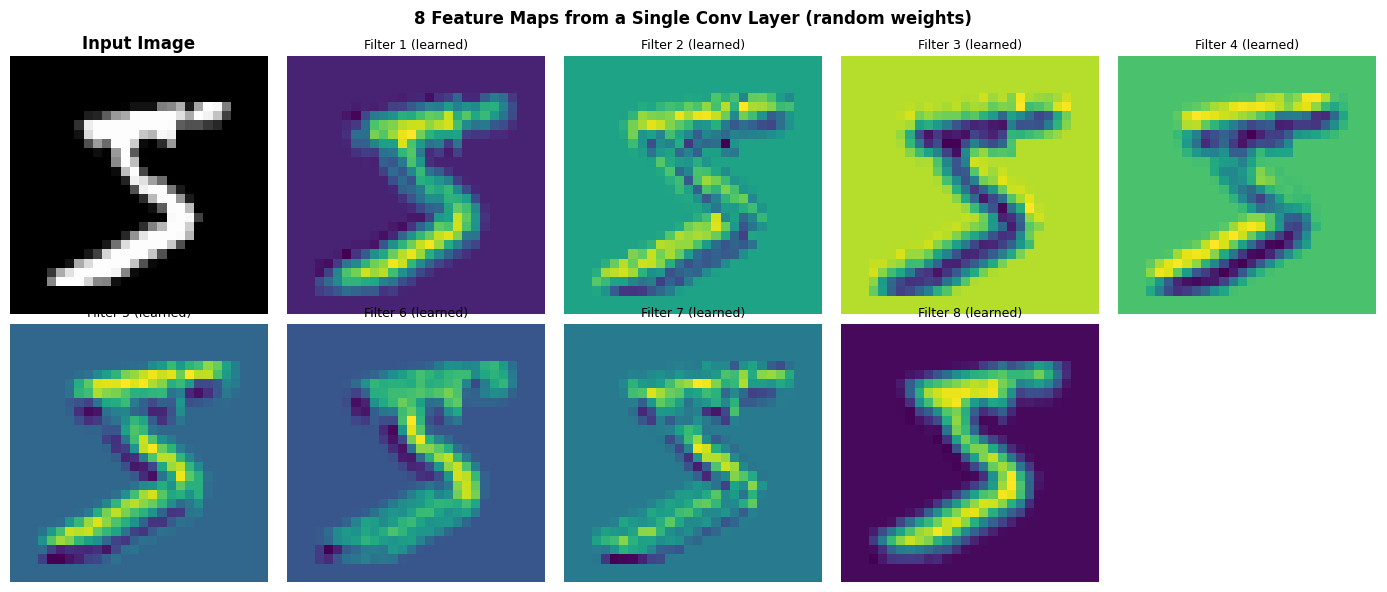

In [9]:
# Visualize learned feature maps after one conv layer
conv_layer = nn.Conv2d(1, 8, kernel_size=3, padding=1)  # 8 filters

img_batch = img.unsqueeze(0)   # (1, 1, 28, 28)

with torch.no_grad():
    feature_maps = conv_layer(img_batch)   # (1, 8, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0, 0].imshow(img_np, cmap='gray')
axes[0, 0].set_title("Input Image", fontweight='bold')
axes[0, 0].axis('off')

for i in range(8):
    row, col = divmod(i + 1, 5)
    fm = feature_maps[0, i].numpy()
    axes[row, col].imshow(fm, cmap='viridis')
    axes[row, col].set_title(f"Filter {i+1} (learned)", fontsize=9)
    axes[row, col].axis('off')

axes[1, 4].axis('off')
plt.suptitle("8 Feature Maps from a Single Conv Layer (random weights)", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 11.4 Building a CNN

A typical CNN architecture:

```
Input (1×28×28)
  → Conv2d(1→32, 3×3) + ReLU          →  32×28×28
  → MaxPool2d(2×2)                     →  32×14×14
  → Conv2d(32→64, 3×3) + ReLU         →  64×14×14
  → MaxPool2d(2×2)                     →  64×7×7
  → Flatten                            →  3136
  → Linear(3136→128) + ReLU           →  128
  → Dropout(0.5)
  → Linear(128→10)                     →  10 (logits)
```


In [10]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional blocks
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 1→32 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 28→14
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32→64 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 14→7
        )
        # Fully connected head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        return self.classifier(x)

cnn = CNNClassifier()
print(cnn)

# Compare parameter counts
mlp_params = sum(p.numel() for p in nn.Sequential(
    nn.Flatten(), nn.Linear(784,256), nn.ReLU(), nn.Linear(256,128), nn.ReLU(), nn.Linear(128,10)
).parameters())
cnn_params = sum(p.numel() for p in cnn.parameters())

print(f"\nMLP parameters: {mlp_params:>10,}")
print(f"CNN parameters: {cnn_params:>10,}  ← fewer params, better spatial understanding")


CNNClassifier(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

MLP parameters:    235,146
CNN parameters:    421,642  ← fewer params, better spatial understanding


In [11]:
# ── Train the CNN ──
train_loader = DataLoader(
    datasets.MNIST('./data', train=True,  download=True,
                   transform=transforms.Compose([transforms.ToTensor(),
                                                  transforms.Normalize((0.1307,),(0.3081,))])),
    batch_size=128, shuffle=True)
test_loader = DataLoader(
    datasets.MNIST('./data', train=False, download=True,
                   transform=transforms.Compose([transforms.ToTensor(),
                                                  transforms.Normalize((0.1307,),(0.3081,))])),
    batch_size=128, shuffle=False)

optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, correct = 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            if train: optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11} {'Test Loss':>11} {'Test Acc':>10}")
print("-"*55)
train_losses, test_accs = [], []
for epoch in range(1, 6):
    tr_l, tr_a = run_epoch(cnn, train_loader, optimizer, criterion, train=True)
    te_l, te_a = run_epoch(cnn, test_loader,  optimizer, criterion, train=False)
    train_losses.append(tr_l); test_accs.append(te_a)
    print(f"{epoch:>6} {tr_l:>12.4f} {tr_a:>10.2%} {te_l:>11.4f} {te_a:>10.2%}")


 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.2608     91.98%      0.0517     98.22%
     2       0.0884     97.36%      0.0477     98.36%
     3       0.0674     97.98%      0.0321     98.85%
     4       0.0517     98.41%      0.0283     99.00%
     5       0.0461     98.65%      0.0255     99.18%


AttributeError: 'numpy.ndarray' object has no attribute 'abs'

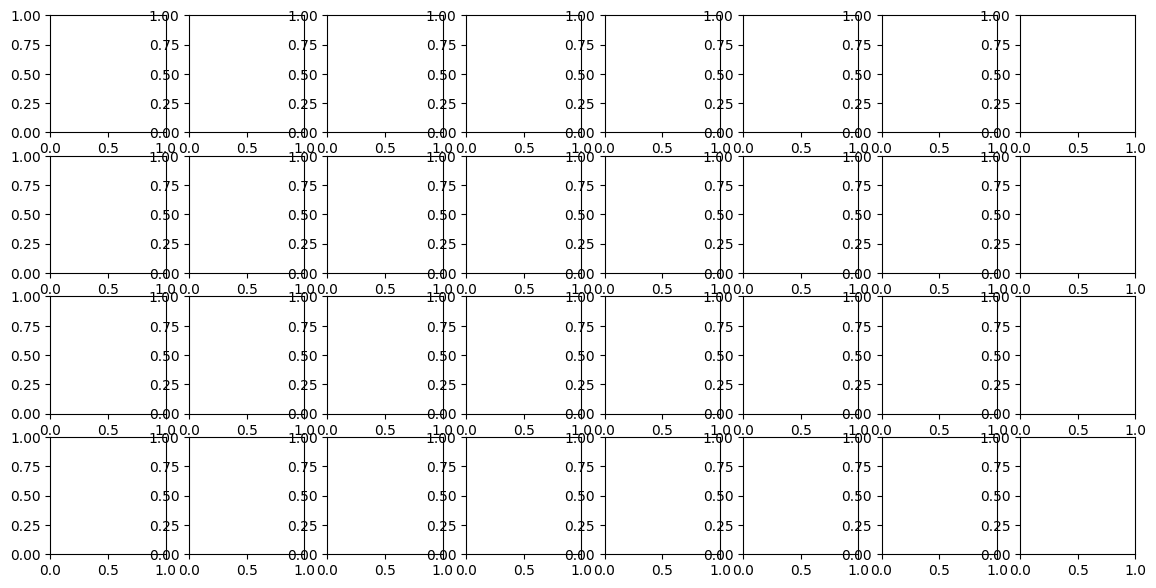

In [12]:
# Visualize what each CNN filter has learned (first conv layer)
filters_learned = cnn.conv_block1[0].weight.data  # shape: (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    f = filters_learned[i, 0].numpy()
    im = ax.imshow(f, cmap='RdBu', vmin=-f.abs().max(), vmax=f.abs().max())
    ax.axis('off')
plt.suptitle("32 Learned 3×3 Filters (first conv layer) Each detects a different low-level feature", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 11.5 MLP vs CNN — Side by Side

| | MLP | CNN |
|---|---|---|
| Treats pixels as | Independent | Spatially related |
| Weight sharing | No | Yes (same filter everywhere) |
| Params for 28×28 image | ~200K (first layer) | ~320 (first conv layer) |
| Translation invariant | No | Yes |
| Good for | Tabular data | Images, spatial data |


## ✏️ Exercises

1. **Receptive field:** What is the receptive field size after 2 layers of 3×3 convolutions (no pooling)? After adding a 2×2 MaxPool between them?
2. **Architecture:** Modify `CNNClassifier` to add a third conv block with 128 filters. How does the parameter count change?
3. **Visualize:** After training, pick 5 misclassified examples and display them with their predicted and true labels. What patterns do you notice?
4. **Experiment:** Remove both `MaxPool2d` layers. What happens to the parameter count and training speed?
